In [1]:
from resources.imports import *

In [2]:
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, RationalQuadratic as RQ, Matern
from sklearn.gaussian_process.kernels import WhiteKernel, ExpSineSquared as Exp
from sklearn.gaussian_process.kernels import Kernel
from sklearn.model_selection import GridSearchCV

# TODO: Cleanup importsz

from resources.MLdata import *
from resources.MLfunc import *
from resources.MLmodels import GPRmodel

Hyperparameter Optimisation

Random Search
Grid-assisted Manual Search

Sequential Model-Based Optimization (SMBO)
- Gaussian Proccess (GP)
- Tree-structured Parzen Estimator (TPE)

In [3]:
DAT = DATA(path=1, load=True, LAT="FCC", dis="disNodes", dN=20, model="GPR", format=1)

# Gaussian Process Regressor (GPR) Hyperparameters & Optimization

In [4]:
def GPR_HPopt(data, gpr, params, cv=5, verb=0):                  # TODO: Finish hopt
    grid_search = GridSearchCV(gpr, params, cv=cv, scoring=None, verbose=verb)
    return grid_search.fit(data[0], data[1])

In [7]:
Ckernel1 = C()*Exp(length_scale=24, periodicity=1)
Ckernel2 = C()*Exp(length_scale=24, periodicity=1)*RQ(length_scale=24, alpha=0.5, 
           length_scale_bounds=(1e-5, 2), alpha_bounds=(1e-5, 1e5))
Ckernel3 = C()*Exp(length_scale=24, periodicity=1)*(RQ(length_scale=24, alpha=0.5, 
           length_scale_bounds=(1e-5, 2), alpha_bounds=(1e-5, 1e5)) + Exp(length_scale=24, periodicity=1))

l, l_bounds = 5, (1e-5, 1e5)
a, a_bounds = 1, (1e-9, 1e9)
p, p_bounds = 1, (1e-9, 1e9)
kernel1 = RBF(length_scale=l)#, length_scale_bounds=l_bounds)  # C(length, (1e-3, 1e3)) * 
kernel2 = RQ(length_scale=l, alpha=a, length_scale_bounds=l_bounds, alpha_bounds=a_bounds)
kernel3 = Matern(length_scale=l, length_scale_bounds=l_bounds, nu=.5)
kernel4 = Exp(length_scale=l, periodicity=p, length_scale_bounds=l_bounds, periodicity_bounds=p_bounds)
kernel5 = WhiteKernel(noise_level=1e-3)

kernels = [kernel1, kernel2, kernel3, kernel4, kernel5, Ckernel1, Ckernel2, Ckernel3]
alphas = [1e-20, 1e-10, 1e-5, 1e-3, 1e-2]
params = {"kernel": kernels, "alpha": alphas}

search_data = [DAT.train_in1, DAT.dx_out1[0]]  
search = GPR_HPopt(search_data, GPR(), params)

search.best_estimator_, search.best_params_["kernel"] 

# Distribution Function Optimization
Unique function approximations from perfect lattice coorindates to each disorder ($\Delta$) distribution.

In [11]:
gpr1 = GPRmodel(K=kernel1, restarts=5, alpha=1e-5, data=[DAT.train_in1, DAT.dx_out1[1]])

c:\Programs\Python39\lib\site-packages\sklearn\gaussian_process\kernels.py:402: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn("The optimal value found for "


In [12]:
gpr1.GPR.kernel_, len(gpr1.GPR.alpha_)

(RBF(length_scale=1e-05), 450)

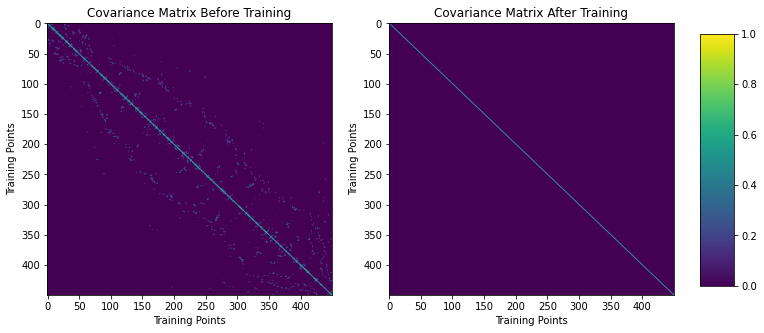

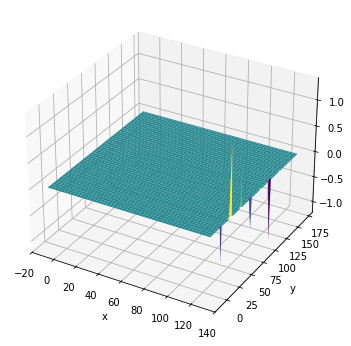

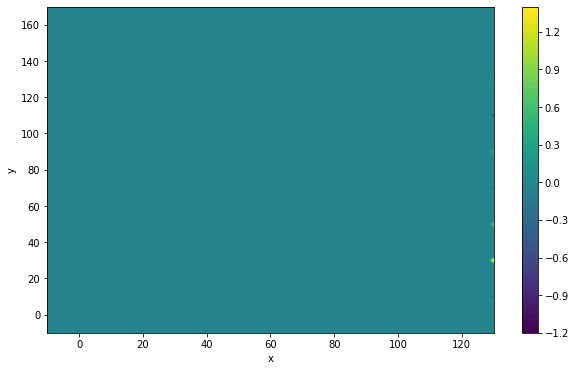

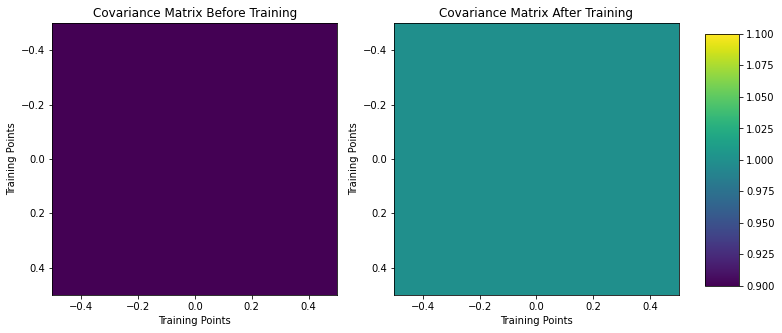

In [13]:
plot_Kmatrix(gpr1)
x_coords, y_coords, mean, std, cov = Fsurface(gpr=gpr1, density=100)
plot_Fsurface(x_coords, y_coords, mean, typ="both")
plot_Kmatrix(gpr1, x_coords)

# Stress-Strain Curve Optimization
General approximation from change in node coordinate components to change in stress-strain curve.

In [14]:
gpr2 = GPRmodel(K=kernel1, restarts=5, alpha=0.3, data=[DAT.train_in[:500], DAT.train_out[:500]])
gpr2.fit(DAT.train_in, DAT.train_out)

y_mean, y_std = gpr2.predict(DAT.test_in, return_std=True)

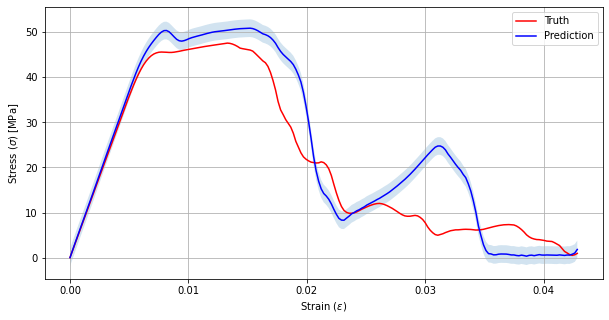

In [20]:
PLTidx = 100

fig = plt.figure(num=1, figsize=(10,5))

plt.ylabel("Stress ($\sigma$) [MPa]")
plt.xlabel("Strain ($\epsilon$)")
plt.plot(DAT.perOUT[0], DAT.test_out[PLTidx]+DAT.perOUT[1], 'r-', label="Truth")
plt.plot(DAT.perOUT[0], y_mean[PLTidx]+DAT.perOUT[1], 'b-', label="Prediction")
plt.fill_between(DAT.perOUT[0], y_mean[PLTidx]+DAT.perOUT[1]-1.96*y_std[PLTidx], y_mean[PLTidx]+DAT.perOUT[1]+1.96*y_std[PLTidx], alpha=0.2)

plt.grid()
plt.legend()
